# 高阶投资组合优化 (Modern Portfolio Optimization)

原教旨的马科维茨 (Markowitz) 均值-方差优化 (MVO) 被称为“估计误差放大器 (Error Maximizer)”。因为它是极度极端的，只要你预期某一两只股票稍微好一点点，它就会梭哈买满。

## 1. 拯救 MVO 的神器：Black-Litterman 模型

高盛研发的 Black-Litterman (BL) 模型优雅地结合了客观市场的均衡规律与你的量化模型的主观观点。

1.  **市场均衡 (Prior)**: 反向应用 CAPM，逆向推导出现有市场对各项资产隐含的长期基准预期收益率。它稳固且分散。
2.  **主观观点 (Investor Views)**: 你的机器学习模型预测“AAPL 会跑赢 5%”。
3.  **贝叶斯融合 (Bayesian Blending)**: BL模型框架将“基准信念”与“偏离观点”通过置信度加以融合，得到非常平滑合理的新预期收益后验分布。

## 2. 赌徒的终极武器：凯利公式 (Kelly Criterion)

如果在多次重复博弈中，已知胜率和赔率，每次下注该占总仓位多少才能实现**资金长期复利最大化**并避免破产？

**二元赌局 Kelly 公式：**
$$ f^* = p - \frac{q}{b} $$
($p$ 是胜率，$q$ 是失败率，$b$ 是赔率/盈亏比。

**连续金融市场 Kelly：**
$$ f^* = \frac{\mu}{\sigma^2} $$
($\mu$ 为超额期望收益，$\sigma^2$ 为策略方差。

### 危险与改良：Half-Kelly
由于现实中估计出的 $\mu$ 和 $\sigma^2$ 会有极大误差，全仓满上 Kelly 会遭遇“爆仓死局”。华尔街常见的做法是 **“Half-Kelly”** (凯利算出来的仓位砍半)，牺牲一丝丝理论最高复利增速，却大幅减去了下行风险！


In [3]:
import matplotlib.pyplot as plt

# 1. 设置系统自带的中文字体（这里使用黑体 SimHei）
plt.rcParams['font.sans-serif'] = ['SimHei']  # 如果你想用微软雅黑，可以改成 ['Microsoft YaHei']

# 2. 解决更换字体后，负号（-）显示为方块的问题
plt.rcParams['axes.unicode_minus'] = False

In [1]:
def kelly_fraction(win_prob, win_loss_ratio):
    """
    简化的离散博弈 Kelly 公式
    """
    if win_loss_ratio <= 0:
        return 0
    q = 1 - win_prob
    f_star = win_prob - (q / win_loss_ratio)
    return max(0, f_star) # 不能借钱，仓位最小为0

print(f"胜率 60%, 盈亏比 1:1 的理论最优押注比例 (Full Kelly): {kelly_fraction(0.60, 1.0):.2%}")
print(f"胜率 55%, 盈亏比 1.5:1 的理论最优押注比例: {kelly_fraction(0.55, 1.5):.2%}")
print(f"---- 实战中通常使用 Half-Kelly 以极大地降低破产风险 ----")
print(f"Half-Kelly (55%胜率, 1.5赔率): {kelly_fraction(0.55, 1.5)/2:.2%}")


胜率 60%, 盈亏比 1:1 的理论最优押注比例 (Full Kelly): 20.00%
胜率 55%, 盈亏比 1.5:1 的理论最优押注比例: 25.00%
---- 实战中通常使用 Half-Kelly 以极大地降低破产风险 ----
Half-Kelly (55%胜率, 1.5赔率): 12.50%


## 3. 实战可视化：不同 Kelly 比例对长期资金曲线的影响

为了直观展示为什么必须要用 Kelly 公式（以及为什么要打折用 Half-Kelly），我们模拟一个胜率为 60%、盈亏比为 1:1 的抛硬币赌局（典型的优秀量化策略特征）。

*   算出的 Full Kelly 最优下注比例是 20%。
*   我们对比：**瞎蒙梭哈 (40% 仓位)**、**Full Kelly (20% 仓位)**、和 **Half-Kelly (10% 仓位)** 的表现。


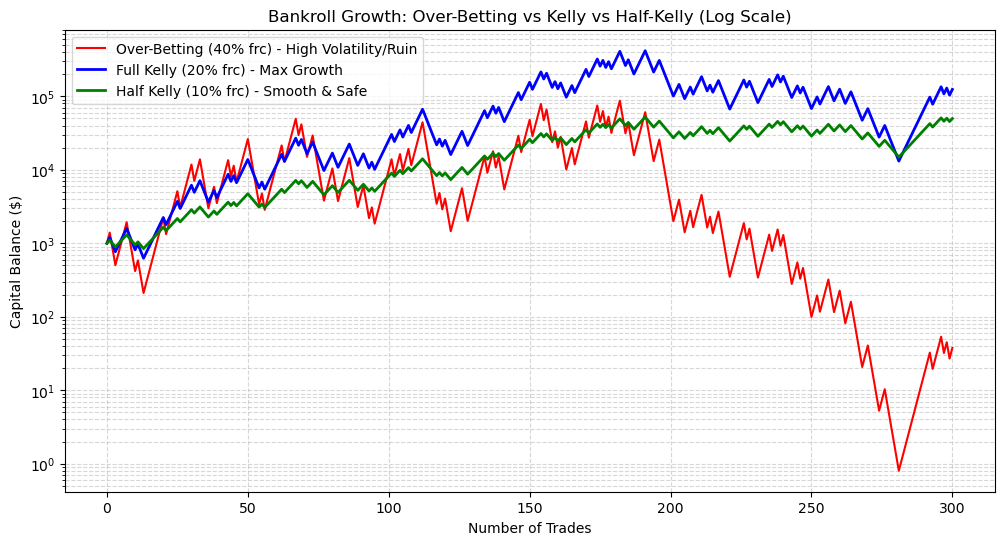

In [2]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
num_flips = 300
win_prob = 0.60

# 生成 300 次赌局结果：1为赢，-1为输
results = np.random.choice([1, -1], size=num_flips, p=[win_prob, 1 - win_prob])

def simulate_bankroll(initial_capital, fraction, results):
    bankroll = [initial_capital]
    for r in results:
        # 每天下注的绝对金额 = 昨天的总资金 * 下注比例
        bet_size = bankroll[-1] * fraction
        profit = bet_size * 1.0 if r == 1 else -bet_size * 1.0
        bankroll.append(bankroll[-1] + profit)
    return bankroll

initial_capital = 1000

bankroll_overbet = simulate_bankroll(initial_capital, 0.40, results)  # 过度杠杆 (危险)
bankroll_full_kelly = simulate_bankroll(initial_capital, 0.20, results) # 理论最优
bankroll_half_kelly = simulate_bankroll(initial_capital, 0.10, results) # 实战常用

plt.figure(figsize=(12, 6))
plt.plot(bankroll_overbet, label='Over-Betting (40% frc) - High Volatility/Ruin', color='red')
plt.plot(bankroll_full_kelly, label='Full Kelly (20% frc) - Max Growth', color='blue', linewidth=2)
plt.plot(bankroll_half_kelly, label='Half Kelly (10% frc) - Smooth & Safe', color='green', linewidth=2)

plt.yscale('log') # 资金曲线通常用对数坐标系展示复利
plt.title('Bankroll Growth: Over-Betting vs Kelly vs Half-Kelly (Log Scale)')
plt.xlabel('Number of Trades')
plt.ylabel('Capital Balance ($)')
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.show()


上面的图表深刻地揭示了量化资金管理的两个基本定律：
1.  **过度杠杆 (Over-Betting) 必定破产**：当你下注超过 Kelly 临界点时（红线），即使你拥有一个胜率 60% 的无敌策略，资金依然会由于巨大的波动性损耗（Volatility Drag）而向下蒸发。
2.  **Half-Kelly 的防守反击**：绿线虽然最终绝对收益不如蓝线（Full Kelly），但它的曲线极其平滑。在真实世界中（胜率可能随时衰减到 55%），Half-Kelly 是保住你不被强平下牌桌的活命底线。

## 教程终章：量化之道的全景图

在这个从头打造的、全面拓展的量化交易教程中，我们从最简单的移动平均线开始，一路攀登到了机构级量化研究的峰顶。

让我们回顾一下我们建立的知识大厦：
1.  **数据与信号 (Phase 1 & 2)**：不要相信表面的价格，去追求平稳的**收益率序列**（ADF检验）。不要相信短期的**相关性**，去寻找长期的**协整吸引力**（Engle-Granger）。
2.  **策略与提纯 (Phase 3 & 4)**：从固定参数的均线过渡到了能够消除未来函数、动态追踪的**卡尔曼滤波器 (Kalman Filter)**。从看图炒股，过渡到了用**信息系数 (IC)** 和 **Alphalens** 来评价抽象因子。
3.  **盾牌与组合 (Phase 4 & 5)**：利用 **PCA** 找出并剥离大盘风险，执行**风险中性优化**。在用机器学习构建非线性模型时，死死守住 **Purged K-Fold** 的底线防止泄漏；在最后下注时，用 **Kelly 公式**管理仓位。

**量化交易从来不是寻找一个百发百中的神奇公式，而是一套极度严谨地管理概率、剥离风险、控制回撤的统计学工程。**

祝你在充满噪音的金融数据海洋中，猎取属于你的纯净 Alpha！


## 🎯 练习

1. 推导连续形式的 Kelly 公式：f* = μ/σ²，使用你的策略历史收益率输入，计算建议的最优仓位比例。
2. 在 Black-Litterman 框架的理论基础上，查阅 `PyPortfolioOpt` 库，对 5 只真实股票实现一次完整的 BL 优化。
3. 模拟 Full Kelly 与 Half Kelly 在连续 3 年的真实 SPY 周收益率上的资金曲线，分析两者的最大回撤差距。

---
**下一节** → `../README.md（教程完结，恭喜！）`
